# Setup

## Installs

In [1]:
!pip install rsatoolbox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.7/734.7 kB 3.1 MB/s eta 0:00:00


## Imports

In [41]:
import numpy as np
import rsatoolbox
from tqdm.autonotebook import tqdm
import itertools

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

## Functions

In [43]:
def create_filepaths_dict_from_folder(folder_path):
    """
    Creates a dictionary of .npy file paths from a given folder.

    Args:
        folder_path (str): The path to the folder containing .npy files.

    Returns:
        dict: A dictionary where keys are filenames (without extension) and values are full file paths.
    """
    filepaths_dict = {}
    for filename in os.listdir(folder_path):
        if filename.endswith('.npy'):
            key = os.path.splitext(filename)[0]
            full_filepath = os.path.join(folder_path, filename)
            filepaths_dict[key] = full_filepath
    return filepaths_dict

In [2]:
def load_npy_file(filepath, verbose=False):
    """
    Loads a .npy file from the given filepath.

    Args:
        filepath (str): The path to the .npy file.

    Returns:
        numpy.ndarray: The data loaded from the .npy file.
    """
    data = np.load(filepath)
    if verbose:
        print(f"Successfully loaded {filepath}")
    return data

In [12]:
def load_rdm(filepath, rdm_method, subset_perc=100):
    features_npy = load_npy_file(filepath)
    if subset_perc < 100:
        features_npy = features_npy[:int(subset_perc / 100 * len(features_npy))]
    features_dataset = rsatoolbox.data.Dataset(features_npy)
    rdm = rsatoolbox.rdm.calc_rdm(features_dataset, method=rdm_method)

    return rdm

In [11]:
def load_rdm_dict(filepaths_dict, rdm_method, rdm_subset_perc=100):
    """
    Loads multiple RDMs from a dictionary of filepaths.

    Args:
        filepaths_dict (dict): A dictionary where keys are identifiers and values are filepaths to .npy files.
        rdm_method (str): The method to use for RDM calculation (e.g., 'correlation').
        rdm_subset_perc (int, optional): Percentage of the features array to use for computing the RDM. Defaults to 100.

    Returns:
        dict: A dictionary of loaded rsatoolbox.rdm.RDMs objects, with keys matching filepaths_dict.
    """
    rdms = {}
    for key, filepath in tqdm(filepaths_dict.items()):
        rdms[key] = load_rdm(filepath, rdm_method, subset_perc=rdm_subset_perc)
    return rdms

In [22]:
def rsa(rdm_a, rdm_b, rsa_method):
    similarity_info = rsatoolbox.rdm.compare(rdm_a, rdm_b, method=rsa_method)
    return similarity_info[0][0], similarity_info

In [29]:
def compute_all_rsa_combinations(rdms_dict, rsa_method):
    """
    Computes RSA between all unique combinations of RDMs in a dictionary.

    Args:
        rdms_dict (dict): A dictionary where keys are RDM identifiers and values are rsatoolbox.rdm.RDMs objects.
        rsa_method (str): The method to use for RSA calculation (e.g., 'rho-a').

    Returns:
        dict: A dictionary where keys are strings representing the RDM pair (e.g., 'RDM_A_vs_RDM_B')
              and values are the similarity scores.
    """
    rsa_results = {}
    keys = list(rdms_dict.keys())
    # Calculate total combinations for tqdm
    total_combinations = len(keys) * (len(keys) - 1) // 2

    # Get all unique combinations of two RDMs (avoiding A-B and B-A, and A-A)
    for rdm_key_a, rdm_key_b in tqdm(itertools.combinations(keys, 2), total=total_combinations, desc="Computing RSA combinations"):
        rdm_a = rdms_dict[rdm_key_a]
        rdm_b = rdms_dict[rdm_key_b]

        similarity, _ = rsa(rdm_a, rdm_b, rsa_method=rsa_method)
        pair_name = f"{rdm_key_a}_vs_{rdm_key_b}"
        rsa_results[pair_name] = similarity

    return rsa_results

In [37]:
def visualize_rsa_matrix(rsa_results, rdm_keys, rsa_method="Similarity"):
    """
    Visualizes RSA results as a symmetric matrix.

    Args:
        rsa_results (dict): A dictionary of RSA similarity scores from compute_all_rsa_combinations.
                            Keys are 'RDM_A_vs_RDM_B', values are similarity scores.
        rdm_keys (list): A list of the keys used for the RDMs (e.g., ['A', 'B', 'C']).
        rsa_method (str, optional): The name of the RSA method for the plot title/colorbar label.
                                    Defaults to "Similarity".
    """
    n_rdms = len(rdm_keys)
    # Initialize an empty matrix with 1s on the diagonal (RDM vs itself)
    rsa_matrix = np.identity(n_rdms)

    # Create a mapping from key to index
    key_to_idx = {key: i for i, key in enumerate(rdm_keys)}

    # Fill the upper and lower triangles of the matrix
    for pair_name, similarity_score in rsa_results.items():
        parts = pair_name.split('_vs_')
        if len(parts) == 2:
            key_a, key_b = parts[0], parts[1]
            idx_a = key_to_idx[key_a]
            idx_b = key_to_idx[key_b]
            rsa_matrix[idx_a, idx_b] = similarity_score
            rsa_matrix[idx_b, idx_a] = similarity_score # Ensure symmetry
        else:
            print(f"Warning: Could not parse pair name {pair_name}")

    # Convert to DataFrame for better heatmap labeling
    rsa_df = pd.DataFrame(rsa_matrix, index=rdm_keys, columns=rdm_keys)

    plt.figure(figsize=(n_rdms * 0.8, n_rdms * 0.7))
    sns.heatmap(rsa_df, annot=True, cmap='viridis', fmt=".2f",
                linewidths=.5, cbar_kws={'label': f'RSA {rsa_method}'})
    plt.title(f'RSA Similarity Matrix ({rsa_method})')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Settings

In [46]:
# Mount google drive for getting the data
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [44]:
folder_path = '/content'  # @param {type:"string"}
rdm_subset_perc = 100/12 # @param {type:"number"} Percentage of the features array used for computing the RDM. 10 means that only a 10% of the vector will be used
rdm_method = "correlation"  # @param {type:"string"}
rsa_method = "rho-a"  # @param {type:"string"}

# Experiments

In [ ]:
filepaths_dict = create_filepaths_dict_from_folder(folder_path)
filepaths_dict

In [33]:
rdm_dict = load_rdm_dict(filepaths_dict, rdm_method=rdm_method, rdm_subset_perc=rdm_subset_perc)

  0%|          | 0/10 [00:00<?, ?it/s]

In [35]:
rsa_results = compute_all_rsa_combinations(rdm_dict, rsa_method)

Computing RSA combinations:   0%|          | 0/45 [00:00<?, ?it/s]

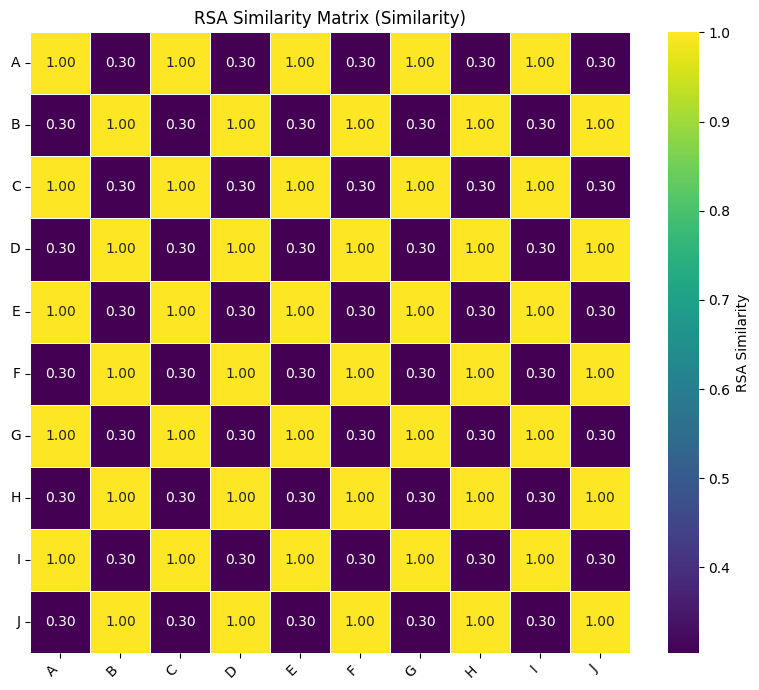

In [42]:
visualize_rsa_matrix(rsa_results, rdm_dict.keys())

In [ ]:
# Legacy code for computing and individual RSA and visualizing RDMs
"""
similarity, similarity_info = rsa(rdm_dict["A"], rdm_dict["B"], rsa_method=rsa_method)
print(f"RSA Alignment Score ({rsa_method}): {similarity:.4f}")

rsatoolbox.vis.show_rdm(rdm_dict["A"])
rsatoolbox.vis.show_rdm(rdm_dict["B"])
"""